In [3]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as c
import astropy.units as u
from torch.utils.data import Dataset
import torch

In [4]:
def cd_sed(nu, Beta, T, a=1):
    nu_c = 545 #GHz
    h_over_k = (c.h/c.k_B/(1*u.K)).to('GHz-1').value
    return a*(nu/nu_c)**(Beta+1)*(np.exp(h_over_k*nu_c/T) - 1)/(np.exp(h_over_k*nu/T) - 1)

def integral(bp_shift, Beta, T, bp_dat):
    return np.sum(bp_dat[1]*cd_sed(bp_dat[0]+bp_shift, Beta, T))

def draw_uniform_within(min, max):
    u = np.random.random()
    return u*(max-min) + min


class VectorScalarDataset(Dataset):
    def __init__(self, X, y):
        """
        X: Tensor of shape (N, p) — inputs
        y: Tensor of shape (N,)   — scalar targets
        """
        self.X = X.float()
        self.y = y.float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

Text(0.5, 0, '$\\nu$ [GHz]')

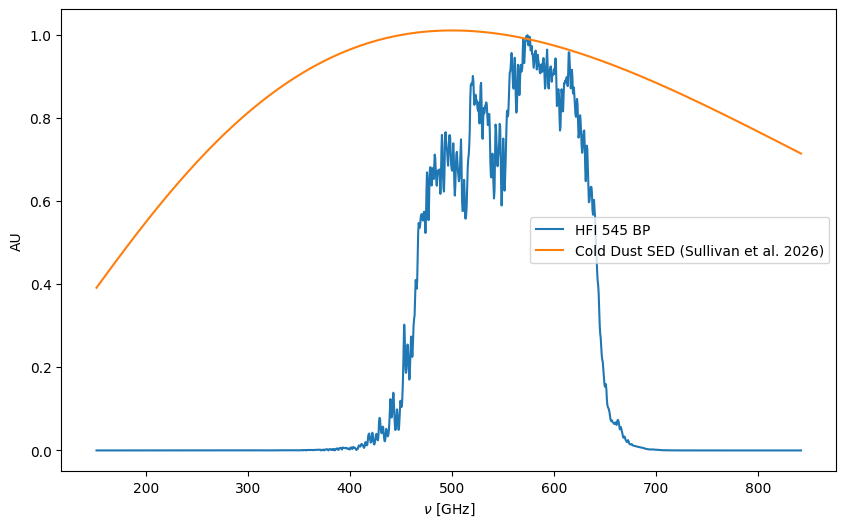

In [6]:
plt.figure(figsize=(10,6))
plt.plot(bp_dat[0], bp_dat[1], label="HFI 545 BP")
plt.plot(bp_dat[0], cd_sed(bp_dat[0]-10, 1.6, 10), label="Cold Dust SED (Sullivan et al. 2026)")
plt.legend()
# plt.xlim((300,800))
plt.ylabel("AU")
plt.xlabel(r"$\nu$"+" [GHz]")

In [7]:
#ref freq for cold dust nu_c is 545.

In [13]:
samp_intervals = {
    "BP_shift":(-10, 10),
    "Beta":(1.6, 2.2),
    "T":(10, 14)
}

samp_intervals_val = {
    "BP_shift":(-8, 8),
    "Beta":(1.7, 2.1),
    "T":(11, 13)
}

In [14]:
N_train = 100
N_val = 22

params = []
ints = []
#training dataset
if False:
    for bp_s_i in range(N_train):
        bp_s = draw_uniform_within(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1])
        for beta_i in range(N_train):
            beta = draw_uniform_within(samp_intervals["Beta"][0], samp_intervals["Beta"][1])
            for t_i in range(N_train):
                t = draw_uniform_within(samp_intervals["T"][0], samp_intervals["T"][1])
                params.append([bp_s, beta, t])
                ints.append(integral(bp_s, beta, t, bp_dat))
    params = np.array(params)
    ints = np.array(ints)

    X = torch.from_numpy(params)
    y = torch.from_numpy(ints)
    dataset = VectorScalarDataset(X, y)
    torch.save({"X": X, "y": y}, "dataset_train.pt")

#validation dataset
params = []
ints = []
if True:
    for bp_s in np.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], num=N_val):
        for beta in np.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], num=N_val):
            for t in np.linspace(samp_intervals["T"][0], samp_intervals["T"][1], num=N_val):
                params.append([bp_s, beta, t])
                # print(params)
                # print(cd_sed(bp_dat[0]+bp_s, beta, t))
                ints.append(integral(bp_s, beta, t, bp_dat))
                # print(integral(bp_dat, beta, t, bp_dat))
    params = np.array(params)
    ints = np.array(ints)

    X = torch.from_numpy(params)
    y = torch.from_numpy(ints)
    dataset = VectorScalarDataset(X, y)
    torch.save({"X": X, "y": y}, "dataset_val.pt")

print(f"Datasets relative size: {N_val**3/N_train**3*100:.2f} %")

Datasets relative size: 1.06 %


In [12]:
torch.load("dataset_train.pt")

{'X': tensor([[ 2.5531,  1.7737, 13.0998],
         [ 2.5531,  1.7737, 10.3943],
         [ 2.5531,  1.7737, 11.7546],
         ...,
         [-2.6095,  1.7970, 11.2839],
         [-2.6095,  1.7970, 13.4090],
         [-2.6095,  1.7970, 13.6572]], dtype=torch.float64),
 'y': tensor([870.4904, 862.7988, 867.0431,  ..., 864.3108, 867.4417, 867.7595],
        dtype=torch.float64)}